In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RNN, SimpleRNNCell, LSTMCell, GRUCell, Dense, Dropout, LSTM, GRU, SimpleRNN

In [2]:
df = pd.read_csv('Truck_sales.csv')
data = df.iloc[:, 1].values.reshape(-1, 1)

In [3]:
final_metrics = {}

In [4]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [5]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(data_scaled, window_size)
train_size = int(len(X) * 0.8)

In [6]:
#1.TF
X_train_tf, X_test_tf = X[:train_size], X[train_size:]
y_train_tf, y_test_tf = y[:train_size], y[train_size:]

In [7]:
#1.1 TF SimpleRNN
model_rnn = Sequential([
    RNN([SimpleRNNCell(64), SimpleRNNCell(32)], input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train_tf, y_train_tf, epochs=100, batch_size=16, verbose=0)

mse_rnn = model_rnn.evaluate(X_test_tf, y_test_tf, verbose=0)
final_metrics["TF RNN"] = mse_rnn

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


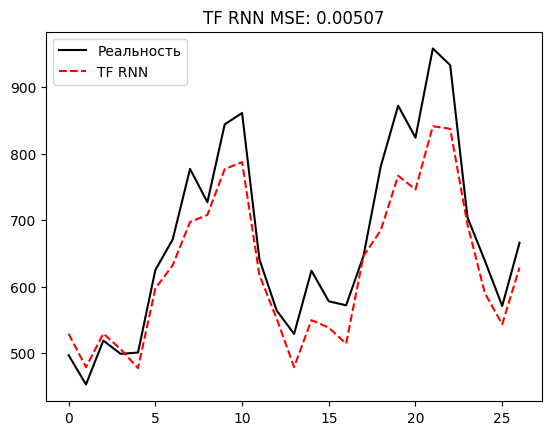

In [8]:
preds = model_rnn.predict(X_test_tf)
plt.plot(scaler.inverse_transform(y_test_tf), label='Реальность', color='black')
plt.plot(scaler.inverse_transform(preds), label='TF RNN', color='red', ls='--')
plt.title(f"TF RNN MSE: {mse_rnn:.5f}"); plt.legend(); plt.show()


In [9]:
#1.2 TF LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_tf, y_train_tf, epochs=100, batch_size=16, verbose=0)

mse_lstm = model_lstm.evaluate(X_test_tf, y_test_tf, verbose=0)
final_metrics["TF LSTM"] = mse_lstm

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step


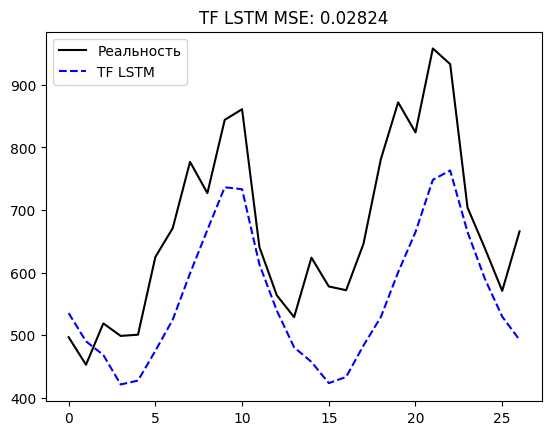

In [10]:
preds = model_lstm.predict(X_test_tf)
plt.plot(scaler.inverse_transform(y_test_tf), label='Реальность', color='black')
plt.plot(scaler.inverse_transform(preds), label='TF LSTM', color='blue', ls='--')
plt.title(f"TF LSTM MSE: {mse_lstm:.5f}"); plt.legend(); plt.show()

In [11]:
#1.3 TF LSTM
model_gru = Sequential([
    GRU(64, return_sequences=True, reset_after=True, input_shape=(window_size, 1)),
    GRU(32, reset_after=True),
    Dropout(0.2),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train_tf, y_train_tf, epochs=100, batch_size=16, verbose=0)

mse_gru = model_gru.evaluate(X_test_tf, y_test_tf, verbose=0)
final_metrics["TF GRU"] = mse_gru

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step


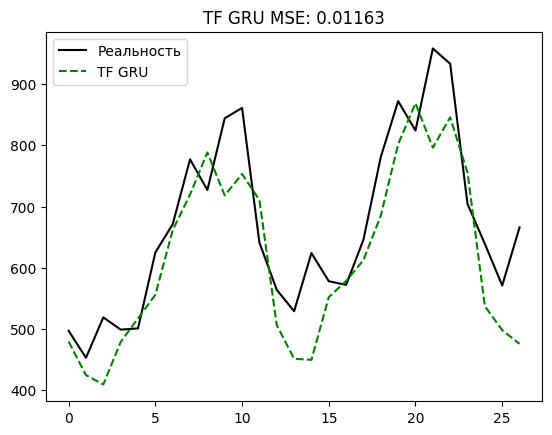

In [12]:
preds = model_gru.predict(X_test_tf)
plt.plot(scaler.inverse_transform(y_test_tf), label='Реальность', color='black')
plt.plot(scaler.inverse_transform(preds), label='TF GRU', color='green', ls='--')
plt.title(f"TF GRU MSE: {mse_gru:.5f}"); plt.legend(); plt.show()

In [13]:
#1.PT
X_train_pt = torch.FloatTensor(X[:train_size])
y_train_pt = torch.FloatTensor(y[:train_size])
X_test_pt = torch.FloatTensor(X[train_size:])
y_test_pt = torch.FloatTensor(y[train_size:])

In [14]:
class TimeSeriesModel(nn.Module):
    def __init__(self, cell_type):
        super().__init__()
        if cell_type == 'RNN': self.layer = nn.RNN(1, 64, num_layers=2, batch_first=True)
        elif cell_type == 'LSTM': self.layer = nn.LSTM(1, 64, num_layers=2, batch_first=True)
        else: self.layer = nn.GRU(1, 64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.layer(x)
        return self.fc(out[:, -1, :])

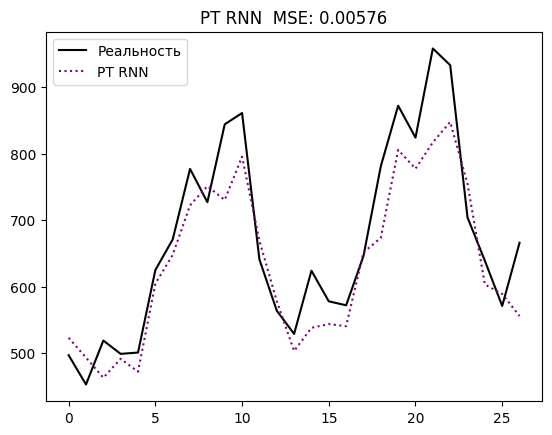

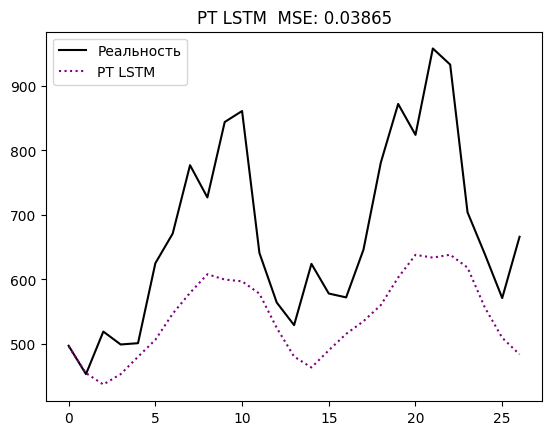

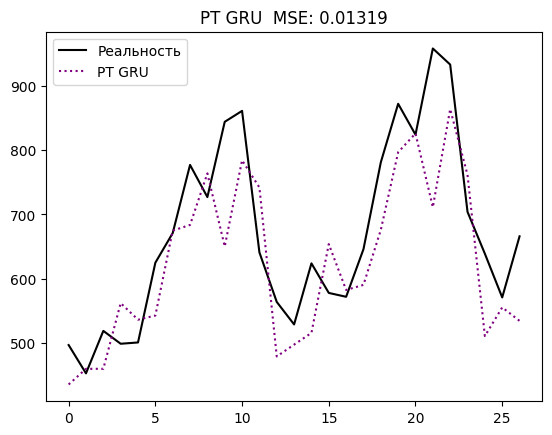

In [15]:
def train_pytorch_model(name):
    model = TimeSeriesModel(name)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    for _ in range(100):
        optimizer.zero_grad()
        loss = criterion(model(X_train_pt), y_train_pt)
        loss.backward(); optimizer.step()

    with torch.no_grad():
        preds = model(X_test_pt)
        mse = criterion(preds, y_test_pt).item()
        final_metrics[f"PT {name}"] = mse

        plt.plot(scaler.inverse_transform(y_test_pt.numpy()), label='Реальность', color='black')
        plt.plot(scaler.inverse_transform(preds.numpy()), label=f'PT {name}', color='purple', ls=':')
        plt.title(f"PT {name}  MSE: {mse:.5f}"); plt.legend(); plt.show()
train_pytorch_model('RNN')
train_pytorch_model('LSTM')
train_pytorch_model('GRU')


In [17]:
sorted_results = sorted(final_metrics.items(), key=lambda x: x[1])
for name, mse in sorted_results:
    print(f"{name:<20}      {mse:.6f}")
print(f"Лучшая модль: {sorted_results[0][0]}")

TF RNN                    0.005066
PT RNN                    0.005758
TF GRU                    0.011632
PT GRU                    0.013192
TF LSTM                   0.028235
PT LSTM                   0.038646
Лучшая модль: TF RNN
